# Caso Práctico: Gráfico Mínimo Viable


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

df = pd.DataFrame({
    'region': np.random.choice(['Norte', 'Centro', 'Sur'], 30),
    'categoria': np.random.choice(['Electrónica', 'Hogar', 'Moda'], 30),
    'ventas_q3_actual': np.random.randint(2000, 15000, 30)
})

# Simular ventas del mismo periodo del año anterior
df['ventas_q3_anterior'] = (df['ventas_q3_actual'] / np.random.uniform(0.8, 1.2, 30)).round(0)

# Calcular YoY
df['yoy'] = (df['ventas_q3_actual'] - df['ventas_q3_anterior']) / df['ventas_q3_anterior']

print("DATASET BASE")
print(df.head())
print("\n")

DATASET BASE
  region categoria  ventas_q3_actual  ventas_q3_anterior       yoy
0    Sur     Hogar              5152              5671.0 -0.091518
1  Norte      Moda             12147             10735.0  0.131532
2    Sur     Hogar              3585              3803.0 -0.057323
3    Sur     Hogar              5943              6514.0 -0.087657
4  Norte      Moda              9555              9395.0  0.017030




YOY PROMEDIO POR CATEGORÍA
     categoria       yoy
1        Hogar -0.075428
2         Moda  0.019080
0  Electrónica  0.025438




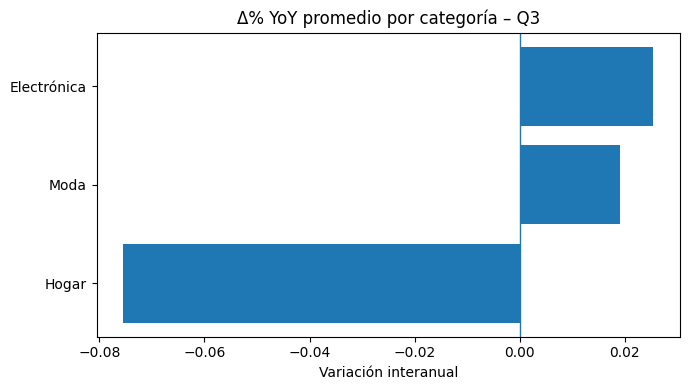

In [ ]:
# 2. ANÁLISIS 1: YOY PROMEDIO POR CATEGORÍA

df_cat = (
    df.groupby('categoria', as_index=False)['yoy']
      .mean()
      .sort_values('yoy')
)

print("YOY PROMEDIO POR CATEGORÍA")
print(df_cat)
print("\n")

plt.figure(figsize=(7, 4))
plt.barh(df_cat['categoria'], df_cat['yoy'])
plt.axvline(0, linewidth=1)
plt.title('Δ% YoY promedio por categoría – Q3')
plt.xlabel('Variación interanual')
plt.tight_layout()
plt.show()


VENTAS TOTALES POR CATEGORÍA
     categoria  ventas_q3_actual  ventas_q3_anterior  yoy_total
0  Electrónica             82503             81504.0   0.012257
1        Hogar             74328             79101.0  -0.060341
2         Moda            110149            112078.0  -0.017211




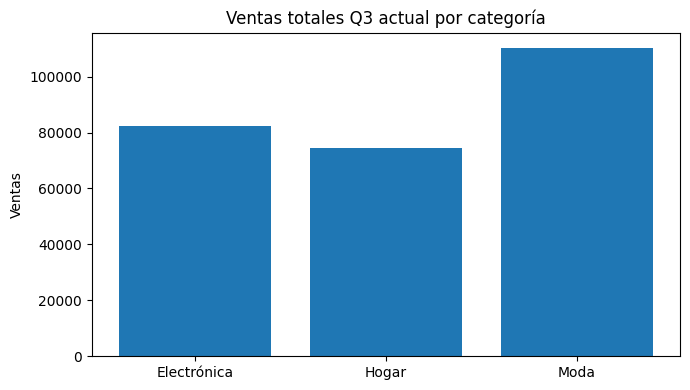

In [ ]:
# 3. ANÁLISIS 2: VENTAS TOTALES POR CATEGORÍA
#    Esto sirve para mostrar que el % por sí solo puede engañar

df_vol = (
    df.groupby('categoria', as_index=False)[['ventas_q3_actual', 'ventas_q3_anterior']]
      .sum()
)

df_vol['yoy_total'] = (
    (df_vol['ventas_q3_actual'] - df_vol['ventas_q3_anterior']) / df_vol['ventas_q3_anterior']
)

print("VENTAS TOTALES POR CATEGORÍA")
print(df_vol)
print("\n")

plt.figure(figsize=(7, 4))
plt.bar(df_vol['categoria'], df_vol['ventas_q3_actual'])
plt.title('Ventas totales Q3 actual por categoría')
plt.ylabel('Ventas')
plt.tight_layout()
plt.show()


In [ ]:
# 4. COMPARAR YOY PROMEDIO VS YOY TOTAL

comparacion = df_cat.merge(
    df_vol[['categoria', 'ventas_q3_actual', 'ventas_q3_anterior', 'yoy_total']],
    on='categoria',
    how='left'
)

print("COMPARACIÓN FINAL")
print(comparacion)
print("\n")


COMPARACIÓN FINAL
     categoria       yoy  ventas_q3_actual  ventas_q3_anterior  yoy_total
0        Hogar -0.075428             74328             79101.0  -0.060341
1         Moda  0.019080            110149            112078.0  -0.017211
2  Electrónica  0.025438             82503             81504.0   0.012257




YOY PROMEDIO POR REGIÓN Y CATEGORÍA
   region    categoria       yoy
2  Centro         Moda -0.170182
1  Centro        Hogar -0.088363
0  Centro  Electrónica -0.013556
3   Norte  Electrónica -0.067680
4   Norte        Hogar -0.054775
5   Norte         Moda  0.088398
7     Sur        Hogar -0.078833
8     Sur         Moda -0.026249
6     Sur  Electrónica  0.077963




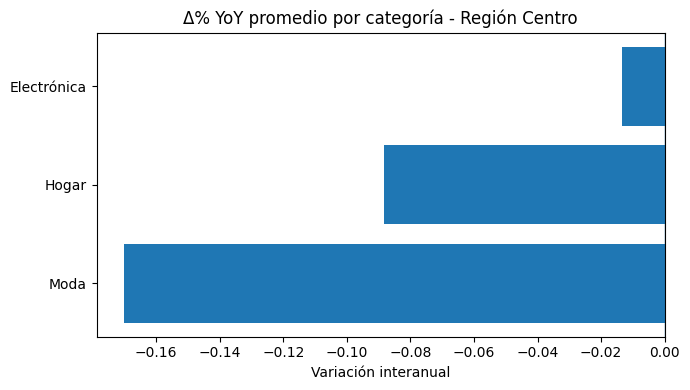

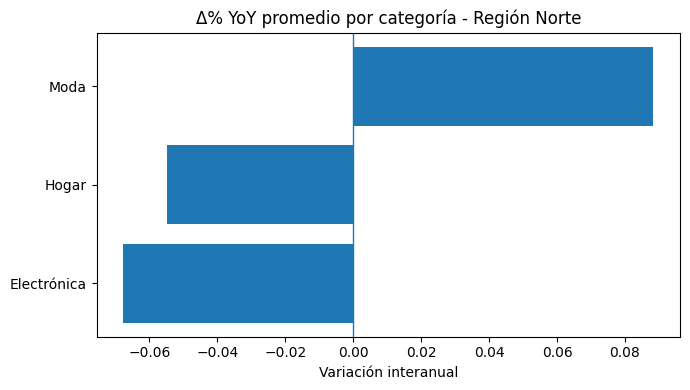

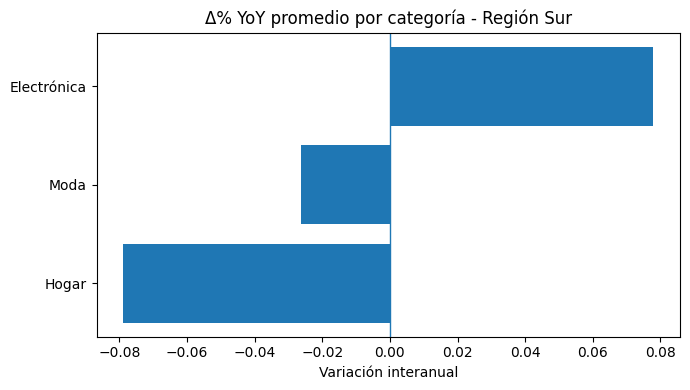

In [ ]:
# 5. ANÁLISIS 3: YOY POR REGIÓN Y CATEGORÍA

df_region_cat = (
    df.groupby(['region', 'categoria'], as_index=False)['yoy']
      .mean()
      .sort_values(['region', 'yoy'])
)

print("YOY PROMEDIO POR REGIÓN Y CATEGORÍA")
print(df_region_cat)
print("\n")

# Graficar una región a la vez para hacerlo simple
regiones = df_region_cat['region'].unique()

for region in regiones:
    temp = df_region_cat[df_region_cat['region'] == region]

    plt.figure(figsize=(7, 4))
    plt.barh(temp['categoria'], temp['yoy'])
    plt.axvline(0, linewidth=1)
    plt.title(f'Δ% YoY promedio por categoría - Región {region}')
    plt.xlabel('Variación interanual')
    plt.tight_layout()
    plt.show()


In [ ]:

# 6. MENSAJES INTERPRETABLES

peor_cat = df_cat.iloc[0]
mejor_cat = df_cat.iloc[-1]

print("INTERPRETACIÓN AUTOMÁTICA")
print(f"La categoría con peor desempeño YoY promedio es: {peor_cat['categoria']} ({peor_cat['yoy']:.2%})")
print(f"La categoría con mejor desempeño YoY promedio es: {mejor_cat['categoria']} ({mejor_cat['yoy']:.2%})")

cat_mayor_volumen = df_vol.sort_values('ventas_q3_actual', ascending=False).iloc[0]
print(f"La categoría con mayor volumen de ventas actual es: {cat_mayor_volumen['categoria']} ({cat_mayor_volumen['ventas_q3_actual']:.0f})")

print("\nOjo:")
print("Una categoría puede tener buen YoY porcentual, pero bajo peso en ventas totales.")
print("Por eso siempre conviene mirar porcentaje + volumen.")

INTERPRETACIÓN AUTOMÁTICA
La categoría con peor desempeño YoY promedio es: Hogar (-7.54%)
La categoría con mejor desempeño YoY promedio es: Electrónica (2.54%)
La categoría con mayor volumen de ventas actual es: Moda (110149)

Ojo:
Una categoría puede tener buen YoY porcentual, pero bajo peso en ventas totales.
Por eso siempre conviene mirar porcentaje + volumen.


# Ejercicio Práctico: Tiempos de Despacho y Satisfacción

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'region': [
        'Norte', 'Norte', 'Norte',
        'Centro', 'Centro', 'Centro',
        'Sur', 'Sur', 'Sur'
    ],
    'tiempo_despacho': [12, 18, 25, 10, 16, 22, 14, 20, 30],
    'nps': [65, 58, 50, 70, 64, 55, 60, 48, 35]
})


In [ ]:
# 2) Metadatos del análisis

fuente = "Base interna de despachos y encuesta NPS"
fecha_corte = "2026-03-08"
definiciones = (
    "NPS: Net Promoter Score promedio por observación. "
    "Tiempo_despacho: horas transcurridas hasta la entrega."
)


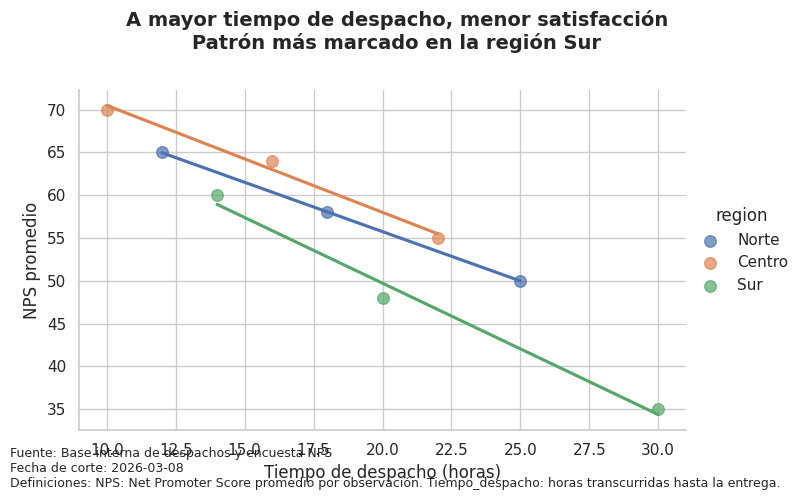

In [ ]:
# 3) Visualización

sns.set_theme(style="whitegrid")

g = sns.lmplot(
    data=df,
    x='tiempo_despacho',
    y='nps',
    hue='region',
    height=5,
    aspect=1.4,
    markers='o',
    scatter_kws={'alpha': 0.7, 's': 70},
    ci=None
)

g.fig.subplots_adjust(top=0.82)

g.fig.suptitle(
    "A mayor tiempo de despacho, menor satisfacción\n"
    "Patrón más marcado en la región Sur",
    fontsize=14,
    fontweight='bold'
)

g.set_axis_labels("Tiempo de despacho (horas)", "NPS promedio")

# Texto con fuente y definiciones
g.fig.text(
    0.02, 0.02,
    f"Fuente: {fuente}\nFecha de corte: {fecha_corte}\nDefiniciones: {definiciones}",
    ha='left',
    va='bottom',
    fontsize=9
)

plt.show()